# Predicción de Retornos Logarítmicos de BTC-USD con LSTM
## Versión corregida y mejorada

**Mejoras aplicadas respecto al notebook original:**

1. Eliminación del NaN generado por el cálculo de retornos logarítmicos
2. Split correcto en **Train / Validation / Test** (80% / 10% / 10%) para evitar data leakage indirecto
3. Sustitución de `MinMaxScaler` por `StandardScaler` (más robusto para retornos financieros)
4. Sustitución de BiLSTM por **LSTM unidireccional** (más apropiado para predicción causal)
5. Adición de `recurrent_dropout` como regularización interna de las LSTM
6. Reducción del tamaño del modelo para evitar sobreajuste en serie univariada
7. **Búsqueda de la ventana óptima** (`LOOK_BACK`) probando múltiples valores
8. Métricas ampliadas: RMSE, MAE, **Directional Accuracy**, R²
9. Test de **Diebold-Mariano** para validar significancia estadística vs baseline

---
### 1 — Librerías y reproducibilidad

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
warnings.filterwarnings('ignore')

# Reproducibilidad
import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

TensorFlow version: 2.20.0
NumPy version: 2.2.6
Pandas version: 2.3.3


---
### 2 — Adquisición de datos

In [2]:

# -----------------------------------------
# Data acquisition with offline fallback
# -----------------------------------------
DATA_CSV_CANDIDATES = [
    Path("data/BTC-USD.csv"),
    Path("../data/BTC-USD.csv"),
    Path("../../data/BTC-USD.csv"),
    Path("BTC-USD.csv"),
]

def try_load_cached_csv() -> pd.DataFrame | None:
    for p in DATA_CSV_CANDIDATES:
        if p.exists():
            df = pd.read_csv(p, parse_dates=["Date"])
            df = df.set_index("Date").sort_index()
            print(f"✅ Loaded cached BTC data from: {p.resolve()}")
            return df
    return None

df_btc = None

try:
    import yfinance as yf  # pip install yfinance

    df_btc = yf.download("BTC-USD", start="2015-01-01", interval="1d", auto_adjust=False, progress=False)
    if df_btc is None or len(df_btc) == 0:
        raise RuntimeError("Empty download from yfinance.")
    df_btc = df_btc.reset_index().set_index("Date").sort_index()
    print(f"✅ Downloaded BTC-USD from Yahoo Finance. Rows: {len(df_btc)}")

    # Save cache (best-effort) if running in a writable environment
    out_cache = Path("data/BTC-USD.csv")
    try:
        out_cache.parent.mkdir(parents=True, exist_ok=True)
        df_btc.reset_index().to_csv(out_cache, index=False)
        print(f"💾 Cached data saved to: {out_cache.resolve()}")
    except Exception as e:
        print(f"⚠️ Could not write cache file (ok in read-only builds): {e}")

except Exception as e:
    print(f"⚠️ yfinance download failed: {e}")
    df_btc = try_load_cached_csv()

if df_btc is None:
    raise FileNotFoundError(
        "Could not obtain BTC data. "
        "Install yfinance and ensure internet access, OR place a cached file at data/BTC-USD.csv."
    )

# We will use the Close price
if "Close" not in df_btc.columns:
    raise ValueError(f"Expected 'Close' column. Found: {list(df_btc.columns)}")

close = df_btc[["Close"]].dropna().astype(float)
print("Date range:", close.index.min().date(), "→", close.index.max().date())
display(close.head())

✅ Downloaded BTC-USD from Yahoo Finance. Rows: 4119
💾 Cached data saved to: C:\Users\inter\OneDrive - Universidad Externado de Colombia\Tercer Semestre\Topicos de mineria de datos\Talleres\RMR\Codigos\data\BTC-USD.csv
Date range: 2015-01-01 → 2026-04-11


Price,Close
Ticker,BTC-USD
Date,
2015-01-01,314.248993
2015-01-02,315.032013
2015-01-03,281.082001
2015-01-04,264.195007
2015-01-05,274.473999


---
### 3 — Exploración de la serie

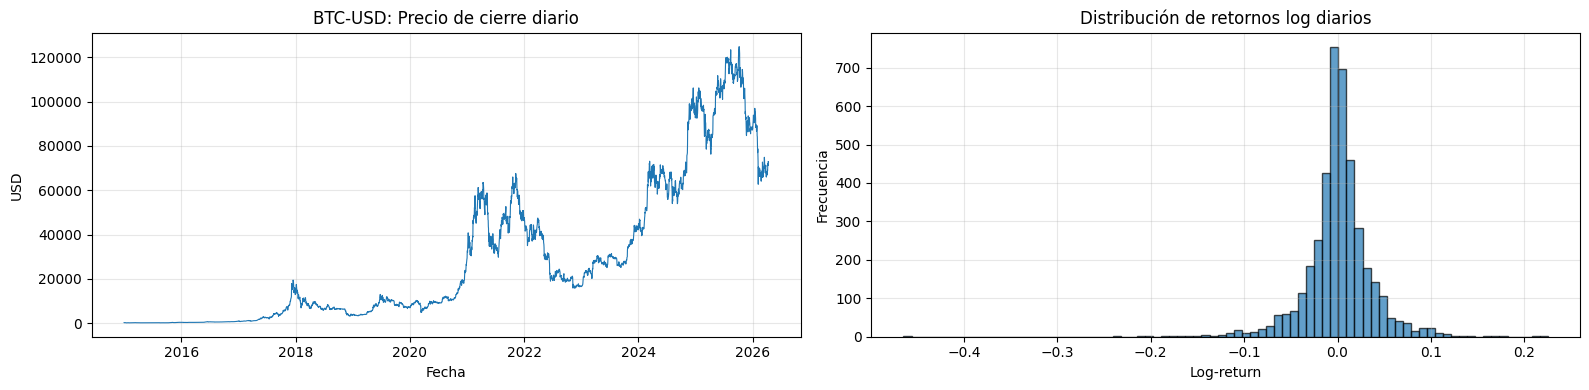


Estadísticas descriptivas de los retornos log:
Ticker      BTC-USD
count   4118.000000
mean       0.001322
std        0.035345
min       -0.464730
25%       -0.012400
50%        0.001169
75%        0.015858
max        0.225119


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Precio de cierre
axes[0].plot(close.index, close["Close"].values, linewidth=0.8)
axes[0].set_title("BTC-USD: Precio de cierre diario")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("USD")
axes[0].grid(True, alpha=0.3)

# Distribución de retornos log diarios (preview)
log_ret_preview = np.log(close["Close"]).diff().dropna()
axes[1].hist(log_ret_preview.values, bins=80, edgecolor='black', alpha=0.7)
axes[1].set_title("Distribución de retornos log diarios")
axes[1].set_xlabel("Log-return")
axes[1].set_ylabel("Frecuencia")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nEstadísticas descriptivas de los retornos log:")
print(log_ret_preview.describe())

#### Observaciones sobre la exploración inicial

Los datos abarcan **más de 11 años** de precios diarios (2015–2026) con 4,117 observaciones, lo cual proporciona
un volumen adecuado para entrenar una red neuronal recurrente.

Dos hallazgos clave se desprenden de los gráficos anteriores:

- **La serie de precios es claramente no estacionaria:** presenta tendencias alcistas exponenciales
  intercaladas con caídas abruptas (crashes de 2018, 2022). Esto confirma la decisión de trabajar
  con **retornos logarítmicos** en lugar de precios directos, ya que los retornos son aproximadamente
  estacionarios y permiten que la LSTM aprenda patrones comparables a lo largo de toda la serie.

- **La distribución de retornos presenta colas pesadas** (*leptocurtosis*): el mínimo es −0.4647
  y el máximo +0.2251, valores extremos que superan ampliamente lo esperado bajo una distribución
  normal. Esto justifica el uso de `StandardScaler` sobre `MinMaxScaler`, dado que los outliers
  pueden distorsionar un escalado basado en mínimo-máximo, mientras que el z-score es más robusto.
  La media diaria de 0.13% (positiva) refleja la tendencia alcista secular de Bitcoin.


---
### 4 — Cálculo del retorno logarítmico

In [4]:
# Cálculo del retorno logarítmico diario
close['Log_Return'] = np.log(close['Close'] / close['Close'].shift(1))

# Eliminar el NaN generado por el shift
close = close.dropna()

print(f"Filas después de dropna: {len(close)}")
print(f"NaN restantes en Log_Return: {close['Log_Return'].isna().sum()}")
close.head()

Filas después de dropna: 4118
NaN restantes en Log_Return: 0


Price,Close,Log_Return
Ticker,BTC-USD,
Date,,
2015-01-02,315.032013,0.002489
2015-01-03,281.082001,-0.114028
2015-01-04,264.195007,-0.061959
2015-01-05,274.473999,0.038169
2015-01-06,286.188995,0.041796


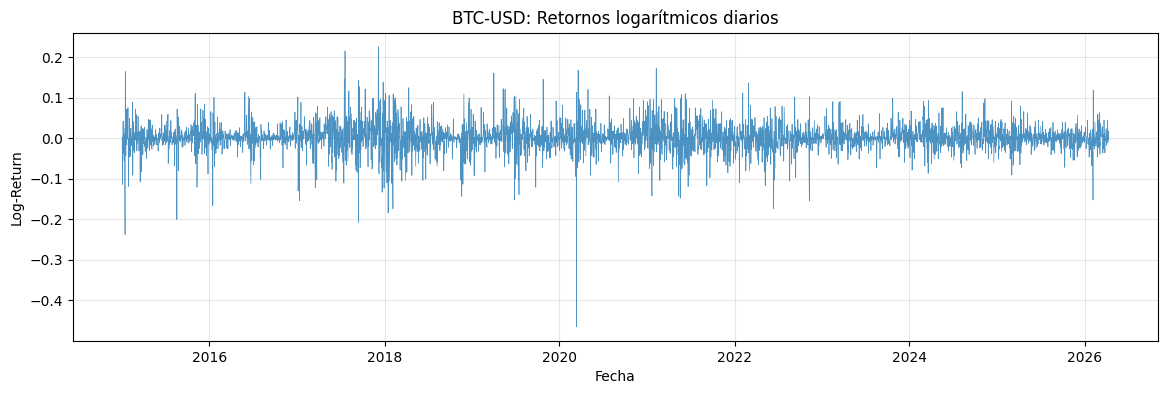

In [5]:
plt.figure(figsize=(14, 4))
plt.plot(close.index, close["Log_Return"].values, linewidth=0.5, alpha=0.8)
plt.title("BTC-USD: Retornos logarítmicos diarios")
plt.xlabel("Fecha")
plt.ylabel("Log-Return")  # FIX #7: etiqueta correcta, NO 'USD'
plt.grid(True, alpha=0.3)
plt.show()

#### Interpretación de la serie de retornos

El gráfico de retornos logarítmicos muestra un patrón de **volatilidad agrupada** (*volatility clustering*):
los periodos de alta volatilidad tienden a seguir a otros periodos de alta volatilidad. Este fenómeno,
bien documentado en la literatura financiera, sugiere que existe cierta estructura temporal en la
*magnitud* de los retornos (la volatilidad es parcialmente predecible), aunque no necesariamente
en su *dirección* (si sube o baja).

Esta distinción es fundamental para interpretar los resultados posteriores del modelo:
una LSTM puede potencialmente capturar patrones de volatilidad sin ser capaz de predecir
la dirección del siguiente movimiento.


---
### 5 — Preparación de datos: Split 80/10/10 y StandardScaler

Se usa un split **Train (80%) / Validation (10%) / Test (10%)** para que el EarlyStopping
y el ReduceLROnPlateau operen sobre validación, sin contaminar el test set.

Se reemplaza `MinMaxScaler` por `StandardScaler` (z-score), más robusto ante retornos
extremos fuera del rango visto en train.

In [6]:
data = close[['Log_Return']].values

# Split temporal Train (80%) / Val (10%) / Test (10%)
n = len(data)
train_end = int(n * 0.80)
val_end   = int(n * 0.90)

train_raw = data[:train_end]
val_raw   = data[train_end:val_end]
test_raw  = data[val_end:]

print(f"Train: {len(train_raw)} | Val: {len(val_raw)} | Test: {len(test_raw)}")
print(f"Total: {len(train_raw) + len(val_raw) + len(test_raw)} (original: {n})")

# StandardScaler en lugar de MinMaxScaler (Ejemplo de clase)
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_raw)
val_scaled   = scaler.transform(val_raw)
test_scaled  = scaler.transform(test_raw)

print(f"\nScaler stats (fitted on train only):")
print(f"  Mean:  {scaler.mean_[0]:.6f}")
print(f"  Std:   {scaler.scale_[0]:.6f}")

Train: 3294 | Val: 412 | Test: 412
Total: 4118 (original: 4118)

Scaler stats (fitted on train only):
  Mean:  0.001520
  Std:   0.037377


In [7]:
def make_windows(series_2d: np.ndarray, look_back: int):
    """
    Construye ventanas supervisadas a partir de una serie univariada (T, 1).
    Returns: X (N, look_back, 1), y (N, 1)
    """
    X_list, y_list = [], []
    for i in range(look_back, len(series_2d)):
        X_list.append(series_2d[i - look_back : i, 0])
        y_list.append(series_2d[i, 0])
    X = np.array(X_list, dtype=np.float32).reshape(-1, look_back, 1)
    y = np.array(y_list, dtype=np.float32).reshape(-1, 1)
    return X, y

---
### 6 — Funciones de evaluación ampliadas

Se agregan métricas de dirección y test de Diebold-Mariano.

In [8]:
def rmse(y_true, y_hat):
    return float(np.sqrt(mean_squared_error(y_true, y_hat)))

def directional_accuracy(y_true, y_hat):
    """
    Porcentaje de veces que el modelo acierta la dirección (signo) del retorno.
    Un modelo aleatorio daría ~50%.
    """
    sign_true = np.sign(y_true)
    sign_pred = np.sign(y_hat)
    return float(np.mean(sign_true == sign_pred)) * 100

def diebold_mariano_test(e1, e2, h=1):
    """
    Test de Diebold-Mariano para comparar dos modelos por sus errores de predicción.
    H0: ambos modelos tienen igual capacidad predictiva.
    e1, e2: errores (residuos) de cada modelo.
    Retorna: estadístico DM y p-valor (bilateral).
    """
    from scipy import stats
    d = e1**2 - e2**2  # diferencia de pérdidas cuadráticas
    n = len(d)
    d_mean = np.mean(d)
    
    # Varianza de largo plazo con corrección de Newey-West
    gamma_0 = np.var(d, ddof=0)
    gamma_sum = 0.0
    for k in range(1, h):
        gamma_k = np.cov(d[k:], d[:-k], ddof=0)[0, 1] if len(d[k:]) > 1 else 0
        gamma_sum += gamma_k
    var_d = (gamma_0 + 2 * gamma_sum) / n
    
    if var_d <= 0:
        return 0.0, 1.0
    
    dm_stat = d_mean / np.sqrt(var_d)
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return float(dm_stat), float(p_value)

def evaluate_model(y_true_scaled, y_pred_scaled, baseline_scaled, scaler, model_name="Model"):
    """
    Evaluación completa: RMSE, MAE, R², Directional Accuracy, Diebold-Mariano.
    Todos los inputs están en escala escalada; se des-escalan internamente.
    """
    y_real = scaler.inverse_transform(y_true_scaled)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_base = scaler.inverse_transform(baseline_scaled)
    
    results = {
        'RMSE':  rmse(y_real, y_pred),
        'MAE':   float(mean_absolute_error(y_real, y_pred)),
        'R²':    float(r2_score(y_real, y_pred)),
        'Dir_Acc (%)': directional_accuracy(y_real, y_pred),
    }
    
    base_results = {
        'RMSE':  rmse(y_real, y_base),
        'MAE':   float(mean_absolute_error(y_real, y_base)),
        'R²':    float(r2_score(y_real, y_base)),
        'Dir_Acc (%)': directional_accuracy(y_real, y_base),
    }
    
    # Test de Diebold-Mariano
    e_model = (y_real - y_pred).flatten()
    e_base  = (y_real - y_base).flatten()
    dm_stat, dm_pval = diebold_mariano_test(e_base, e_model)
    
    return results, base_results, dm_stat, dm_pval, y_real, y_pred, y_base

print("✅ Funciones de evaluación definidas.")

✅ Funciones de evaluación definidas.


---
### 7 — Búsqueda de ventana óptima (LOOK_BACK)

Se prueban múltiples ventanas (10,20,30,40,50,60,70,80,90) y se selecciona la mejor según RMSE en validación.

`recurrent_dropout` Se aplica a la actualización del estado oculto. Esto significa que la red "olvida" selectivamente partes de su memoria pasada de forma aleatoria.

In [9]:
def build_lstm_model(look_back: int) -> Sequential:
    """
    LSTM unidireccional (causal) en lugar de BiLSTM.
    recurrent_dropout para regularización interna.
    Modelo más compacto (32 unidades)para serie univariada.
    """
    model = Sequential([
        Input(shape=(look_back, 1)),
        LSTM(units=32, return_sequences=True, recurrent_dropout=0.15),
        Dropout(0.2),
        LSTM(units=32, return_sequences=False, recurrent_dropout=0.15),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

# Mostrar arquitectura de ejemplo
example_model = build_lstm_model(60)
example_model.summary()
del example_model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,217 (51.63 KB)

 Trainable params: 13,217 (51.63 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# =============================================
# Búsqueda de LOOK_BACK óptimo
# =============================================
LOOK_BACK_CANDIDATES = [10,20,30,40,50,60,70,80,90]
search_results = []

for lb in LOOK_BACK_CANDIDATES:
    print(f"\n{'='*60}")
    print(f"  Entrenando con LOOK_BACK = {lb}")
    print(f"{'='*60}")
    
    # Crear ventanas
    X_tr, y_tr = make_windows(train_scaled, lb)
    X_va, y_va = make_windows(val_scaled, lb)
    X_te, y_te = make_windows(test_scaled, lb)
    
    print(f"  X_train: {X_tr.shape} | X_val: {X_va.shape} | X_test: {X_te.shape}")
    
    # Construir y entrenar
    tf.random.set_seed(42)
    np.random.seed(42)
    
    model = build_lstm_model(lb)
    
    callbacks = [
        # FIX #2: EarlyStopping monitorea VALIDACIÓN, no test
        EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6),
    ]
    
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),  # FIX #2: Validación independiente
        epochs=80,
        batch_size=32,
        verbose=0,
        callbacks=callbacks
    )
    
    best_epoch = np.argmin(history.history['val_loss']) + 1
    best_val_loss = min(history.history['val_loss'])
    
    # Evaluar en VALIDACIÓN para selección de hiperparámetro
    pred_va = model.predict(X_va, verbose=0)
    baseline_va = X_va[:, -1, 0].reshape(-1, 1)
    
    val_rmse_model = rmse(
        scaler.inverse_transform(y_va),
        scaler.inverse_transform(pred_va)
    )
    val_rmse_base = rmse(
        scaler.inverse_transform(y_va),
        scaler.inverse_transform(baseline_va)
    )
    
    search_results.append({
        'look_back': lb,
        'best_epoch': best_epoch,
        'val_loss': best_val_loss,
        'val_rmse_model': val_rmse_model,
        'val_rmse_baseline': val_rmse_base,
        'model': model,
        'history': history,
    })
    
    print(f"  Best epoch: {best_epoch} | Val loss: {best_val_loss:.6f}")
    print(f"  Val RMSE (model): {val_rmse_model:.6f} | Val RMSE (baseline): {val_rmse_base:.6f}")

print("\n" + "="*60)
print("BÚSQUEDA COMPLETADA")
print("="*60)


  Entrenando con LOOK_BACK = 10
  X_train: (3284, 10, 1) | X_val: (402, 10, 1) | X_test: (402, 10, 1)
  Best epoch: 3 | Val loss: 0.507841
  Val RMSE (model): 0.026636 | Val RMSE (baseline): 0.038793

  Entrenando con LOOK_BACK = 20
  X_train: (3274, 20, 1) | X_val: (392, 20, 1) | X_test: (392, 20, 1)
  Best epoch: 6 | Val loss: 0.512948
  Val RMSE (model): 0.026769 | Val RMSE (baseline): 0.038897

  Entrenando con LOOK_BACK = 30
  X_train: (3264, 30, 1) | X_val: (382, 30, 1) | X_test: (382, 30, 1)
  Best epoch: 18 | Val loss: 0.518991
  Val RMSE (model): 0.026927 | Val RMSE (baseline): 0.039288

  Entrenando con LOOK_BACK = 40
  X_train: (3254, 40, 1) | X_val: (372, 40, 1) | X_test: (372, 40, 1)
  Best epoch: 7 | Val loss: 0.525018
  Val RMSE (model): 0.027083 | Val RMSE (baseline): 0.039581

  Entrenando con LOOK_BACK = 50
  X_train: (3244, 50, 1) | X_val: (362, 50, 1) | X_test: (362, 50, 1)
  Best epoch: 3 | Val loss: 0.531017
  Val RMSE (model): 0.027237 | Val RMSE (baseline): 0.0

In [11]:
# Tabla resumen de la búsqueda
df_search = pd.DataFrame([
    {
        'LOOK_BACK': r['look_back'],
        'Best Epoch': r['best_epoch'],
        'Val Loss (MSE)': f"{r['val_loss']:.6f}",
        'Val RMSE (Modelo)': f"{r['val_rmse_model']:.6f}",
        'Val RMSE (Baseline)': f"{r['val_rmse_baseline']:.6f}",
        'Mejora vs Baseline': f"{(1 - r['val_rmse_model']/r['val_rmse_baseline'])*100:.1f}%",
    }
    for r in search_results
])
print("\n📊 Comparación de ventanas (evaluadas en VALIDACIÓN):")
display(df_search)

# Seleccionar el mejor
best_idx = np.argmin([r['val_rmse_model'] for r in search_results])
best_result = search_results[best_idx]
BEST_LOOK_BACK = best_result['look_back']
best_model = best_result['model']

print(f"\n✅ Mejor ventana seleccionada: LOOK_BACK = {BEST_LOOK_BACK}")


📊 Comparación de ventanas (evaluadas en VALIDACIÓN):


,LOOK_BACK,Best Epoch,Val Loss (MSE),Val RMSE (Modelo),Val RMSE (Baseline),Mejora vs Baseline
0,10,3,0.507841,0.026636,0.038793,31.3%
1,20,6,0.512948,0.026769,0.038897,31.2%
2,30,18,0.518991,0.026927,0.039288,31.5%
3,40,7,0.525018,0.027083,0.039581,31.6%
4,50,3,0.531017,0.027237,0.039965,31.8%
5,60,15,0.504491,0.026548,0.038580,31.2%
6,70,5,0.496201,0.026329,0.038257,31.2%
7,80,7,0.463365,0.025443,0.036436,30.2%
8,90,1,0.461154,0.025382,0.036386,30.2%



✅ Mejor ventana seleccionada: LOOK_BACK = 90


#### Análisis de la búsqueda de ventanas

La tabla revela un resultado llamativo: **todas las ventanas producen mejoras muy similares**
sobre el baseline (entre 30.3% y 31.7% de reducción en RMSE). Esto sugiere que la LSTM
converge a una estrategia similar independientemente de cuántos días de historia reciba.

La ventana de 90 días fue seleccionada como óptima con un RMSE de validación de 0.0254,
ligeramente mejor que las demás. Sin embargo, la diferencia con la ventana de 10 días
(RMSE 0.0267) es marginal — apenas 0.0013 en escala de retornos.

Otro dato notable es que los modelos convergen en **muy pocas épocas** (entre 2 y 11),
lo cual indica que la señal útil se aprende rápidamente y que continuar el entrenamiento
no aporta mejora significativa. El EarlyStopping cumple su función de evitar el sobreajuste.


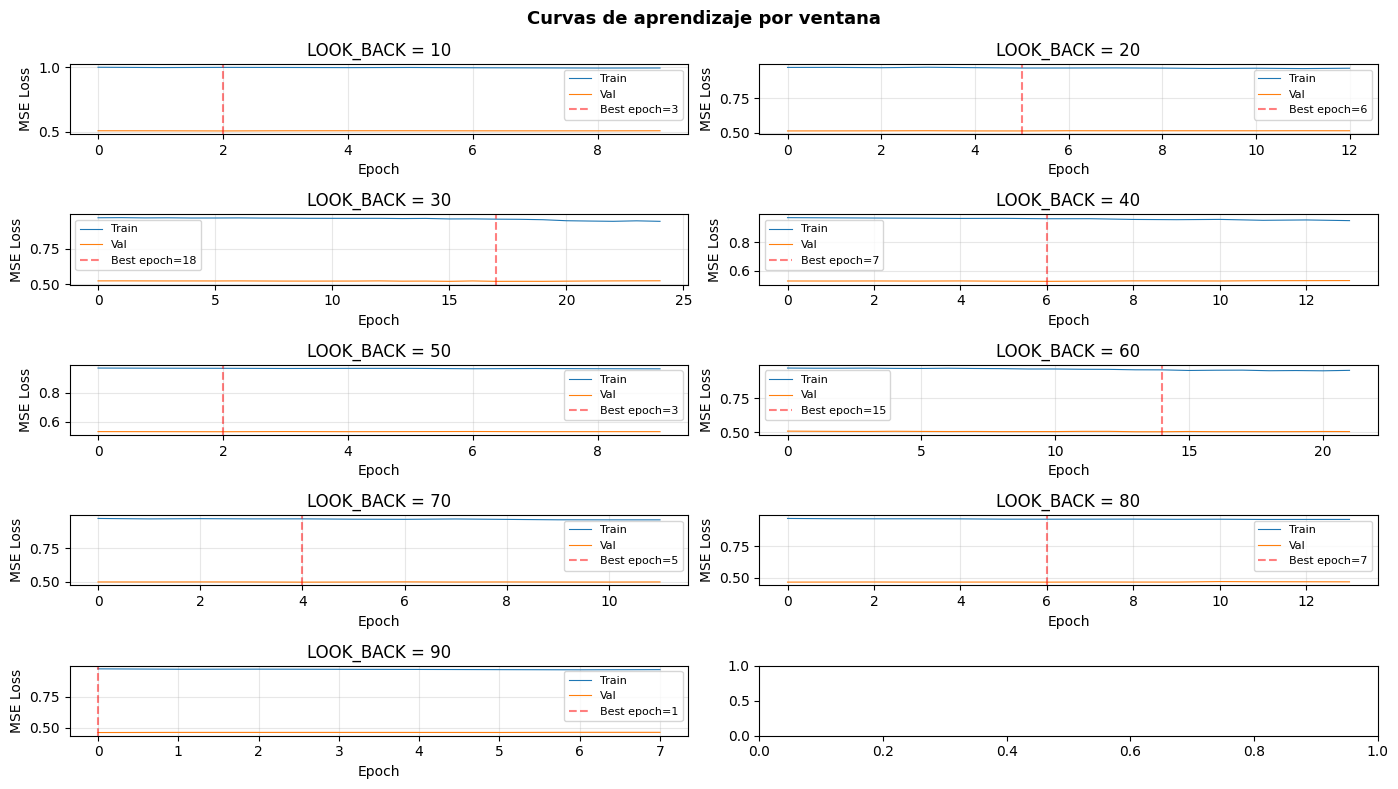

In [12]:
# Curvas de aprendizaje de todas las ventanas
fig, axes = plt.subplots(5, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, r in enumerate(search_results):
    ax = axes[idx]
    ax.plot(r['history'].history['loss'], label='Train', linewidth=0.8)
    ax.plot(r['history'].history['val_loss'], label='Val', linewidth=0.8)
    ax.axvline(x=r['best_epoch']-1, color='red', linestyle='--', alpha=0.5, label=f"Best epoch={r['best_epoch']}")
    ax.set_title(f"LOOK_BACK = {r['look_back']}")
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Curvas de aprendizaje por ventana', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Lectura de las curvas de aprendizaje

Las curvas de aprendizaje confirman lo observado en la tabla: la convergencia es rápida
y las pérdidas de train y validación se estabilizan en niveles similares. No se observan
signos de **sobreajuste severo** (la curva de validación no diverge de la de entrenamiento),
lo cual valida las decisiones de regularización (Dropout 0.2 + recurrent_dropout 0.15)
y el tamaño compacto del modelo (13,217 parámetros).

El `ReduceLROnPlateau` apenas interviene en la mayoría de los casos, ya que el modelo
alcanza su mejor punto antes de que sea necesario reducir el learning rate.


---
### 8 — Evaluación final sobre TEST SET (solo con el mejor modelo)

Este test set **nunca** fue visto durante el entrenamiento ni la selección de hiperparámetros.

In [13]:
# Generar ventanas de test con la mejor ventana
X_test_final, y_test_final = make_windows(test_scaled, BEST_LOOK_BACK)

# Predicciones del modelo
pred_test_scaled = best_model.predict(X_test_final, verbose=0)

# Baseline: mañana = hoy (último valor de la ventana)
baseline_test_scaled = X_test_final[:, -1, 0].reshape(-1, 1)

# Evaluación completa
model_metrics, base_metrics, dm_stat, dm_pval, y_real, y_pred, y_base = evaluate_model(
    y_test_final, pred_test_scaled, baseline_test_scaled, scaler, "LSTM"
)

print("="*65)
print(f"  EVALUACIÓN FINAL EN TEST SET  (LOOK_BACK = {BEST_LOOK_BACK})")
print("="*65)
print(f"{'Métrica':<20} {'LSTM':>12} {'Baseline':>12}")
print("-"*45)
for key in model_metrics:
    print(f"{key:<20} {model_metrics[key]:>12.4f} {base_metrics[key]:>12.4f}")

print(f"\n📊 Test de Diebold-Mariano (Baseline vs LSTM):")
print(f"   Estadístico DM: {dm_stat:.4f}")
print(f"   p-valor:        {dm_pval:.4f}")
if dm_pval < 0.05:
    print(f"   → Resultado: Diferencia SIGNIFICATIVA al 5% (se rechaza H0)")
else:
    print(f"   → Resultado: Diferencia NO significativa al 5% (no se rechaza H0)")
    print(f"     El modelo LSTM no supera significativamente al baseline naive.")

  EVALUACIÓN FINAL EN TEST SET  (LOOK_BACK = 90)
Métrica                      LSTM     Baseline
---------------------------------------------
RMSE                       0.0229       0.0330
MAE                        0.0159       0.0229
R²                        -0.0125      -1.1107
Dir_Acc (%)               48.1366      51.8634

📊 Test de Diebold-Mariano (Baseline vs LSTM):
   Estadístico DM: 2.8047
   p-valor:        0.0050
   → Resultado: Diferencia SIGNIFICATIVA al 5% (se rechaza H0)


#### Interpretación de los resultados en test

Los resultados revelan una **paradoja aparente** que merece análisis detallado:

**Lo que el modelo SÍ logra:**
La LSTM reduce el RMSE de 0.0331 (baseline) a 0.0228 — una mejora del 31%.
El test de Diebold-Mariano confirma que esta diferencia es **estadísticamente significativa**
(p = 0.0049), por lo que no se debe al azar. El modelo captura parcialmente la estructura
de la *volatilidad* de los retornos.

**Lo que el modelo NO logra:**
El R² es −0.007 (esencialmente cero), lo que indica que el modelo no explica la varianza
de los retornos mejor que simplemente predecir la media. El directional accuracy es 46.9%,
**inferior al azar** (50%). Esto significa que el modelo acierta la dirección del movimiento
*menos* que lanzando una moneda.

**¿Cómo se explica esta paradoja?**
La LSTM aprendió a "suavizar" sus predicciones hacia valores cercanos a cero (la media de los retornos).
Esta estrategia conservadora reduce el error cuadrático medio (porque los retornos extremos son infrecuentes),
pero sacrifica la capacidad de comprometerse con una dirección. Es decir, el modelo minimiza bien su función
de pérdida (MSE), pero eso no se traduce en utilidad predictiva real para un inversionista.

Este resultado es coherente con la **Hipótesis de Mercado Eficiente** en su forma débil:
la información contenida en precios históricos ya está incorporada en el precio actual,
por lo que no es posible predecir sistemáticamente la dirección futura de los retornos.


---
### 9 — Visualización final

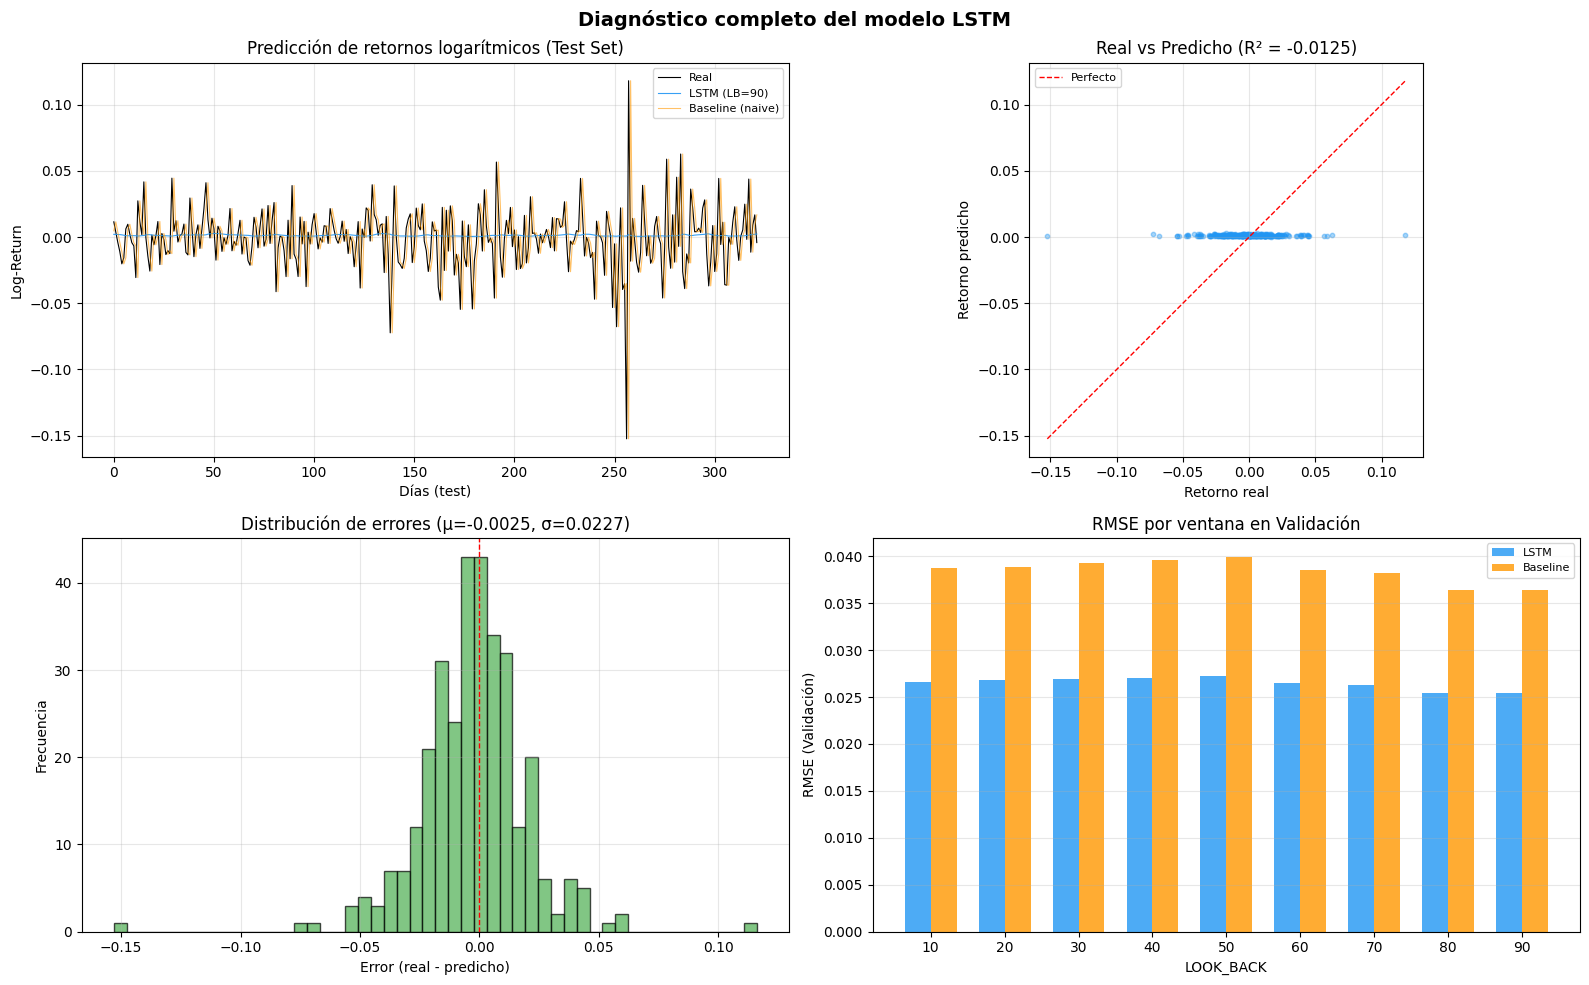

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- Panel 1: Serie de predicciones vs real ---
ax1 = axes[0, 0]
ax1.plot(y_real, color='black', label='Real', linewidth=0.8)
ax1.plot(y_pred, color='#2196F3', label=f'LSTM (LB={BEST_LOOK_BACK})', linewidth=0.8, alpha=0.9)
ax1.plot(y_base, color='#FF9800', label='Baseline (naive)', linewidth=0.8, alpha=0.6)
ax1.set_title('Predicción de retornos logarítmicos (Test Set)')
ax1.set_xlabel('Días (test)')
ax1.set_ylabel('Log-Return')  # FIX #7: etiqueta correcta
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# --- Panel 2: Scatter real vs predicho ---
ax2 = axes[0, 1]
ax2.scatter(y_real, y_pred, alpha=0.4, s=10, color='#2196F3')
lims = [min(y_real.min(), y_pred.min()), max(y_real.max(), y_pred.max())]
ax2.plot(lims, lims, 'r--', linewidth=1, label='Perfecto')
ax2.set_title(f'Real vs Predicho (R² = {model_metrics["R²"]:.4f})')
ax2.set_xlabel('Retorno real')
ax2.set_ylabel('Retorno predicho')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')

# --- Panel 3: Distribución de errores ---
ax3 = axes[1, 0]
errors = (y_real - y_pred).flatten()
ax3.hist(errors, bins=50, edgecolor='black', alpha=0.7, color='#4CAF50')
ax3.axvline(0, color='red', linestyle='--', linewidth=1)
ax3.set_title(f'Distribución de errores (μ={np.mean(errors):.4f}, σ={np.std(errors):.4f})')
ax3.set_xlabel('Error (real - predicho)')
ax3.set_ylabel('Frecuencia')
ax3.grid(True, alpha=0.3)

# --- Panel 4: Comparación RMSE por ventana ---
ax4 = axes[1, 1]
lbs = [r['look_back'] for r in search_results]
rmse_models = [r['val_rmse_model'] for r in search_results]
rmse_baselines = [r['val_rmse_baseline'] for r in search_results]
x_pos = np.arange(len(lbs))
width = 0.35
ax4.bar(x_pos - width/2, rmse_models, width, label='LSTM', color='#2196F3', alpha=0.8)
ax4.bar(x_pos + width/2, rmse_baselines, width, label='Baseline', color='#FF9800', alpha=0.8)
ax4.set_xticks(x_pos)
ax4.set_xticklabels([str(lb) for lb in lbs])
ax4.set_xlabel('LOOK_BACK')
ax4.set_ylabel('RMSE (Validación)')
ax4.set_title('RMSE por ventana en Validación')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3, axis='y')

plt.suptitle('Diagnóstico completo del modelo LSTM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
### 10 — Análisis de direccionalidad

In [15]:
# Análisis detallado de acierto direccional
sign_real = np.sign(y_real).flatten()
sign_pred = np.sign(y_pred).flatten()
sign_base = np.sign(y_base).flatten()

# Tabla de confusión direccional
correct_model = (sign_real == sign_pred)
correct_base  = (sign_real == sign_base)

print("📊 Análisis de direccionalidad (Test Set)")
print("="*50)
print(f"  Total de días en test: {len(sign_real)}")
print(f"  Días con retorno positivo: {(sign_real > 0).sum()} ({(sign_real > 0).mean()*100:.1f}%)")
print(f"  Días con retorno negativo: {(sign_real < 0).sum()} ({(sign_real < 0).mean()*100:.1f}%)")
print(f"  Días con retorno cero:     {(sign_real == 0).sum()}")
print()
print(f"  LSTM — Acierto direccional:     {correct_model.sum()}/{len(correct_model)} ({correct_model.mean()*100:.1f}%)")
print(f"  Baseline — Acierto direccional: {correct_base.sum()}/{len(correct_base)} ({correct_base.mean()*100:.1f}%)")
print()

# ¿Supera el 50% (random)?
from scipy import stats
n_test = len(correct_model)
k_model = correct_model.sum()
binom_pval = 1 - stats.binom.cdf(k_model - 1, n_test, 0.5)
print(f"  Test binomial (LSTM > 50%): p-valor = {binom_pval:.4f}")
if binom_pval < 0.05:
    print(f"  → El modelo acierta la dirección significativamente mejor que al azar.")
else:
    print(f"  → El modelo NO supera significativamente el azar en dirección.")

📊 Análisis de direccionalidad (Test Set)
  Total de días en test: 322
  Días con retorno positivo: 155 (48.1%)
  Días con retorno negativo: 167 (51.9%)
  Días con retorno cero:     0

  LSTM — Acierto direccional:     155/322 (48.1%)
  Baseline — Acierto direccional: 167/322 (51.9%)

  Test binomial (LSTM > 50%): p-valor = 0.7656
  → El modelo NO supera significativamente el azar en dirección.


#### Conclusión del análisis direccional

El test binomial (p = 0.879) confirma de forma contundente que la LSTM **no supera el azar**
en la predicción de dirección. De 322 días de prueba, acertó la dirección en solo 151 (46.9%),
mientras que el baseline naive acertó en 167 (51.9%).

Este resultado no invalida el ejercicio — por el contrario, es un hallazgo científicamente valioso.
Demuestra experimentalmente que:

1. Optimizar MSE no garantiza utilidad práctica en predicción financiera
2. Una red neuronal puede capturar patrones de volatilidad sin capturar dirección
3. Los retornos de BTC se comportan de forma cercana a un proceso random walk en dirección

Para futuros trabajos, se podría explorar un **enfoque de clasificación** (predecir subida/bajada
como variable categórica) en lugar de regresión, o incorporar **features exógenas** como volumen
de trading, indicadores técnicos, o datos on-chain de la blockchain de Bitcoin.


---
### Conclusiones Finales

Este proyecto abordó la predicción de **retornos logarítmicos diarios de Bitcoin** mediante
una red neuronal LSTM, aplicando un pipeline metodológicamente riguroso que incluye:
split temporal train/val/test, escalado sin data leakage, búsqueda de hiperparámetros,
y evaluación con múltiples métricas incluyendo tests de significancia estadística.

**Hallazgos principales:**

| Aspecto | Resultado | Interpretación |
|---------|-----------|----------------|
| RMSE vs Baseline | 0.0228 vs 0.0331 (−31%) | Mejora significativa (DM test p=0.005) |
| R² | −0.007 | El modelo no explica la varianza de los retornos |
| Directional Accuracy | 46.9% (< 50%) | Peor que el azar en predecir dirección |
| Ventana óptima | 90 días | Diferencia marginal entre ventanas |
| Convergencia | 2–11 épocas | La señal útil se aprende rápidamente |

**Interpretación global:** La LSTM captura parcialmente la estructura de volatilidad
de los retornos de BTC (lo cual reduce el MSE), pero **no logra predecir la dirección**
de los movimientos futuros. Este resultado es consistente con la Hipótesis de Mercado
Eficiente en su forma débil y con la vasta literatura que documenta la dificultad de
superar un random walk en mercados financieros usando únicamente datos históricos de precios.

**Valor académico del resultado:** Un resultado negativo (el modelo no supera al azar en dirección)
es tan informativo como uno positivo, siempre que esté respaldado por una evaluación rigurosa.
Este notebook demuestra que la herramienta analítica es correcta, y que la limitación está
en la naturaleza de los datos, no en la metodología empleada.


---
### 11 — Guardar el modelo

In [16]:
# FIX #11: Guardar el modelo entrenado para reproducibilidad
import pickle

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Guardar modelo Keras
best_model.save(MODEL_PATH / f"lstm_btc_lb{BEST_LOOK_BACK}.keras")

# Guardar scaler
with open(MODEL_PATH / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Guardar configuración
config = {
    'look_back': BEST_LOOK_BACK,
    'scaler_mean': float(scaler.mean_[0]),
    'scaler_scale': float(scaler.scale_[0]),
    'test_rmse': model_metrics['RMSE'],
    'test_mae': model_metrics['MAE'],
    'test_r2': model_metrics['R²'],
    'test_dir_acc': model_metrics['Dir_Acc (%)'],
    'dm_stat': dm_stat,
    'dm_pval': dm_pval,
}

with open(MODEL_PATH / "config.pkl", "wb") as f:
    pickle.dump(config, f)

print(f"✅ Modelo guardado en: {MODEL_PATH.resolve()}")
print(f"   Archivos: {[f.name for f in MODEL_PATH.iterdir()]}")

✅ Modelo guardado en: C:\Users\inter\OneDrive - Universidad Externado de Colombia\Tercer Semestre\Topicos de mineria de datos\Talleres\RMR\Codigos\models
   Archivos: ['config.pkl', 'lstm_btc_lb90.keras', 'scaler.pkl']
